##### E-Commerce: Customer Segmentation by Price Sensitivity:-

##### 1. Load and clean the dataset (remove NA, duplicates).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

In [3]:
print("Shape:", df.shape)
print(df.head())

Shape: (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [6]:
df = df.dropna()

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df = df.dropna()

In [9]:
print("Cleaned Shape:", df.shape)

Cleaned Shape: (2216, 29)


2. Visualize spending patterns and demographics

In [ ]:
df["Total_Spending"] = (df["MntWines"] +df["MntFruits"] +df["MntMeatProducts"] +df["MntFishProducts"] +df["MntSweetProducts"] +df["MntGoldProds"])
print(df["Total_Spending"].describe())

count    2216.000000
mean      607.075361
std       602.900476
min         5.000000
25%        69.000000
50%       396.500000
75%      1048.000000
max      2525.000000
Name: Total_Spending, dtype: float64


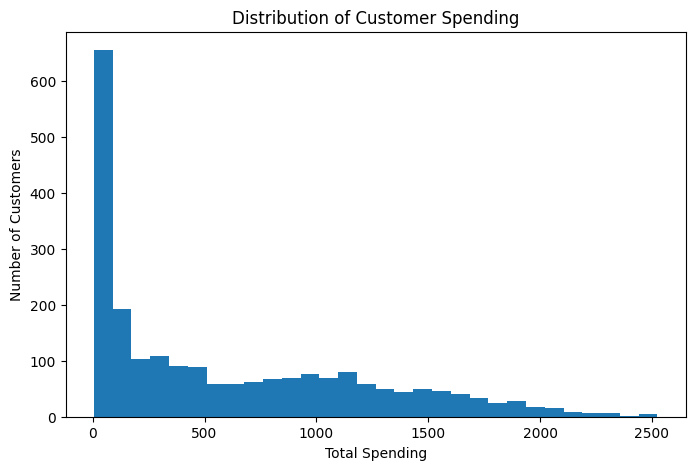

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["Total_Spending"], bins=30)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

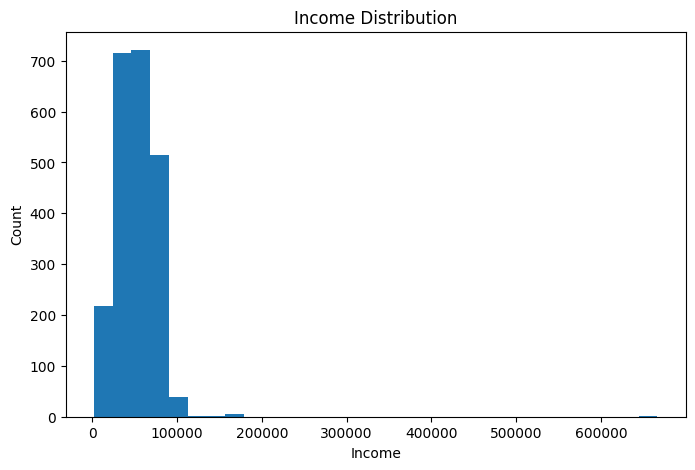

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["Income"], bins=30)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

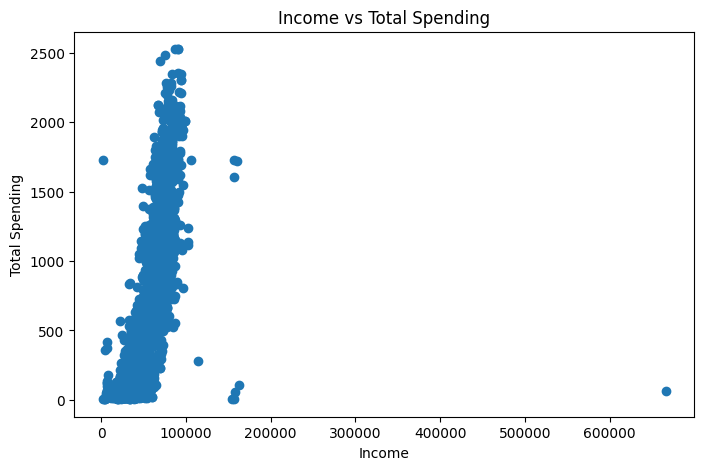

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df["Income"], df["Total_Spending"])
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.show()

3. Normalize numerical features (spending, income).

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[["Income", "Total_Spending"]])

scaled_df = pd.DataFrame(scaled_features,columns=["Income_Scaled", "Spending_Scaled"])

print(scaled_df.head())

   Income_Scaled  Spending_Scaled
0       0.234063         1.675488
1      -0.234559        -0.962358
2       0.769478         0.280250
3      -1.017239        -0.919224
4       0.240221        -0.307044


4. Choose optimal number of clusters using Elbow
method.


In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = scaled_df[["Income_Scaled", "Spending_Scaled"]]

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42,n_init=10)
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


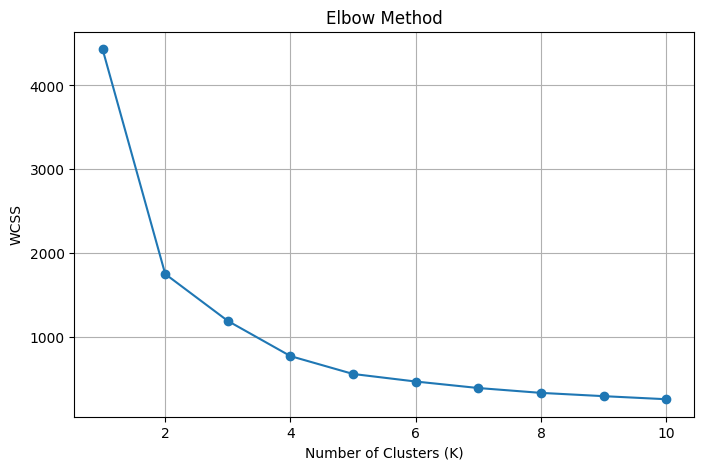

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

5. Apply K-Means clustering

In [ ]:
from sklearn.cluster import KMeans

X = scaled_df[["Income_Scaled", "Spending_Scaled"]]

kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42,n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

print(df[["Income", "Total_Spending", "Cluster"]].head())

    Income  Total_Spending  Cluster
0  58138.0            1617        0
1  46344.0              27        3
2  71613.0             776        1
3  26646.0              53        3
4  58293.0             422        1


6. Apply Hierarchical clustering and compare.

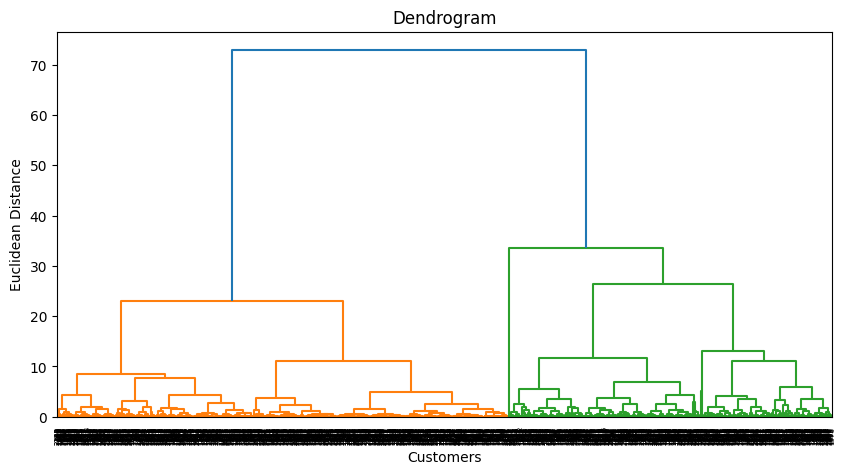

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

X = scaled_df[["Income_Scaled", "Spending_Scaled"]]

# Create Dendrogram
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

7. Visualize clusters using PCA or t-SNE

In [19]:
from sklearn.decomposition import PCA

X = scaled_df[["Income_Scaled", "Spending_Scaled"]]

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X)

pca_df = pd.DataFrame(pca_features,columns=["PC1", "PC2"])

pca_df["Cluster"] = df["Cluster"]

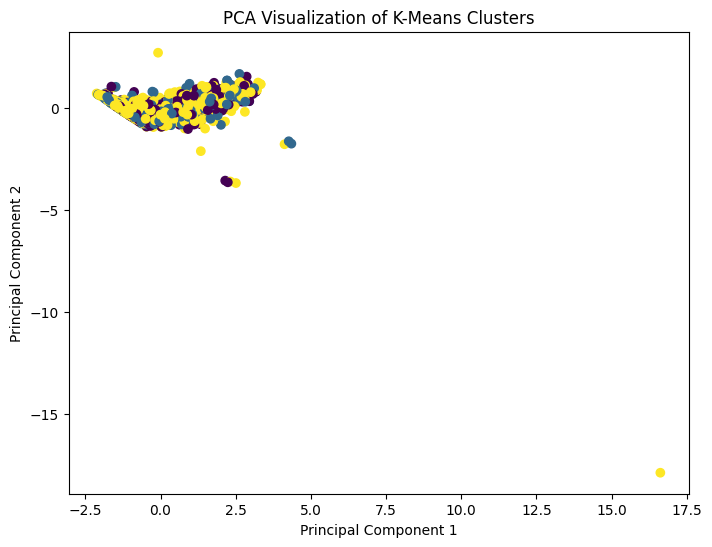

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

8. Profile each cluster (age, income, loyalty).

In [21]:
from datetime import datetime

current_year = datetime.now().year

df["Age"] = current_year - df["Year_Birth"]

In [22]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [23]:
df["Age"] = 2026 - df["Year_Birth"]

cluster_profile = df.groupby("Cluster")[["Age","Income","Recency"]].mean()

print(cluster_profile.round(2))

           Age     Income  Recency
Cluster                           
0        57.99   78159.28    50.38
1        60.04   63527.53    48.73
2        49.00  666666.00    23.00
3        55.22   34726.44    48.65


9. Label original dataset with cluster IDs.

In [24]:
df["Cluster"] = kmeans.labels_

print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp5  AcceptedCmp1  \
0  2012-09-04       58       635  ...             0             0   
1  2014-03-08       38        11  ...             0             0   
2  2013-08-21       26       426  ...             0             0   
3  2014-02-10       26        11  ...             0             0   
4  2014-01-19       94       173  ...             0             0   

   AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response  Total_Spending  \
0             0         0          

10. Recommend marketing strategy per cluster.

In [25]:
cluster_profile = df.groupby("Cluster").agg({"Age": "mean","Income": "mean","Total_Spending": "mean","Recency": "mean"}).round(2)

print(cluster_profile)

           Age     Income  Total_Spending  Recency
Cluster                                           
0        57.99   78159.28         1570.32    50.38
1        60.04   63527.53          767.40    48.73
2        49.00  666666.00           62.00    23.00
3        55.22   34726.44          125.49    48.65
